## 1. Data Loading and Initial Exploration

In [16]:
import pandas as pd

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasets/breast-cancer/refs/heads/main/data/breast-cancer.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events


In [2]:
# Display general information about the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           272 non-null    object
 1   mefalsepause  272 non-null    object
 2   tumor-size    272 non-null    object
 3   inv-falsedes  272 non-null    object
 4   falsede-caps  264 non-null    object
 5   deg-malig     272 non-null    int64 
 6   breast        272 non-null    object
 7   breast-quad   271 non-null    object
 8   irradiat      272 non-null    bool  
 9   class         272 non-null    object
dtypes: bool(1), int64(1), object(8)
memory usage: 19.5+ KB


In [3]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,deg-malig
count,272.000000
mean,2.058824
std,0.736649
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000


## 2. Essential Data Preprocessing: Handling Missing Values

In [4]:
# Check for missing values in each column
print("\nMissing values before imputation:")
display(df.isnull().sum())


Missing values before imputation:


,0
age,0
mefalsepause,0
tumor-size,0
inv-falsedes,0
falsede-caps,8
deg-malig,0
breast,0
breast-quad,1
irradiat,0
class,0


In [5]:
# Impute missing values for 'falsede-caps' and 'breast-quad' with their respective modes
for column in ['falsede-caps', 'breast-quad']:
    if df[column].isnull().any():
        mode_value = df[column].mode()[0]
        df[column].fillna(mode_value, inplace=True)
        print(f"Missing values in '{column}' imputed with mode: {mode_value}")

# Verify that missing values have been handled
print("\nMissing values after imputation:")
display(df.isnull().sum())

Missing values in 'falsede-caps' imputed with mode: False
Missing values in 'breast-quad' imputed with mode: left_low

Missing values after imputation:


/tmp/ipykernel_4043/3125389096.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_value, inplace=True)
/tmp/ipykernel_4043/3125389096.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column].fillna(mode_value, inplace=True)


,0
age,0
mefalsepause,0
tumor-size,0
inv-falsedes,0
falsede-caps,0
deg-malig,0
breast,0
breast-quad,0
irradiat,0
class,0


## 3. Essential Data Preprocessing: Encoding Categorical Features

In [6]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate target variable from features
X = df.drop('class', axis=1)
y = df['class']

# Encode the target variable 'class'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Original target classes: {label_encoder.classes_}")
print(f"Encoded target mapping: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Original target classes: ['false-recurrence-events' 'recurrence-events']
Encoded target mapping: [('false-recurrence-events', np.int64(0)), ('recurrence-events', np.int64(1))]


In [7]:
# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns

# Apply OneHotEncoder to the categorical columns
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = one_hot_encoder.fit_transform(X[categorical_cols])

# Create a DataFrame with the one-hot encoded features
one_hot_df = pd.DataFrame(X_encoded, columns=one_hot_encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns from X and concatenate the one-hot encoded DataFrame
X_final = pd.concat([X.drop(columns=categorical_cols), one_hot_df], axis=1)

print("\nShape of features after one-hot encoding:", X_final.shape)
print("First 5 rows of the processed features (X_final):")
display(X_final.head())


Shape of features after one-hot encoding: (272, 39)
First 5 rows of the processed features (X_final):


,deg-malig,age_20-29,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_ge40,mefalsepause_lt40,mefalsepause_premefalse,...,falsede-caps_True,breast_left,breast_right,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,irradiat_False,irradiat_True
0,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## 4. Essential Data Preprocessing: Standardizing Numerical Features and Splitting Data

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Identify numerical features that were not one-hot encoded
numerical_cols = ['deg-malig']

# Apply StandardScaler to numerical features
scaler = StandardScaler()
X_final[numerical_cols] = scaler.fit_transform(X_final[numerical_cols])

print("\nFeatures after standardization (first 5 rows of numerical columns only):")
display(X_final[numerical_cols].head())


Features after standardization (first 5 rows of numerical columns only):


,deg-malig
0,1.28
1,-1.44
2,-0.08
3,1.28
4,-0.08


In [9]:
# Split the data into training and testing sets
# Using a 80/20 split and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_final, y_encoded, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")



Shape of X_train: (217, 39)
Shape of X_test: (55, 39)
Shape of y_train: (217,)
Shape of y_test: (55,)


## 5. Model Implementation: Logistic Regression Training

In [10]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set solver to 'liblinear' for small datasets and 'lbfgs' for larger ones, or 'saga' for multiclass.
# Using a fixed random_state for reproducibility.
model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [11]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Get probability scores for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions made on the test set.")

Predictions made on the test set.


## 6. Generating Evaluation Metrics

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

Accuracy: 0.7636
Precision: 0.5333
Recall: 0.5714
F1-score: 0.5517
AUC: 0.6629


### Confusion Matrix

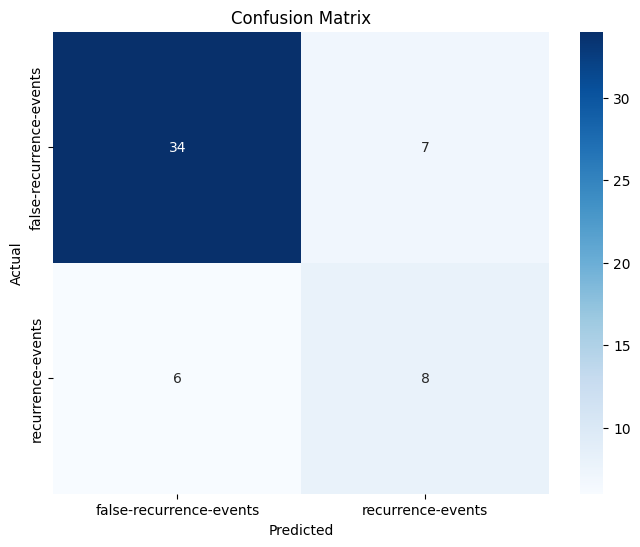

In [13]:
# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### ROC Curve

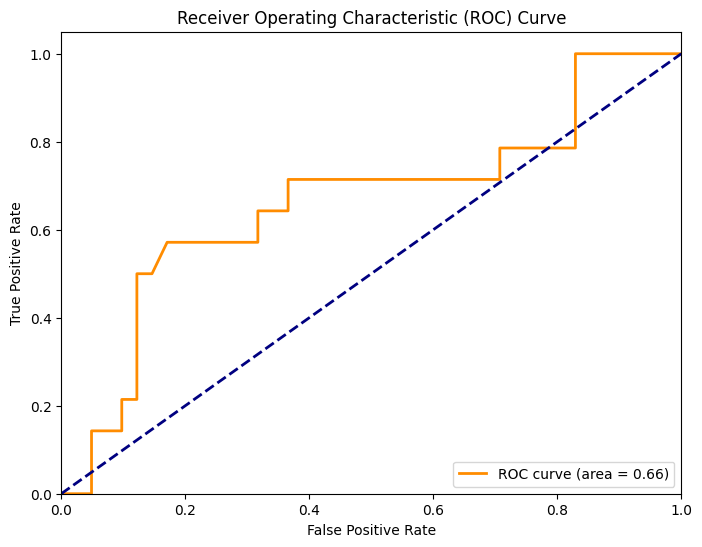

In [14]:
# Generate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### Sample Predictions

In [15]:
# Display sample predictions
predictions_df = pd.DataFrame({
    'Actual': label_encoder.inverse_transform(y_test),
    'Predicted': label_encoder.inverse_transform(y_pred),
    'Probability (Negative Class)': model.predict_proba(X_test)[:, 0].round(3),
    'Probability (Positive Class)': model.predict_proba(X_test)[:, 1].round(3)
})

print("\nSample Predictions (Actual vs. Predicted with Probabilities):")
display(predictions_df.head(10))


Sample Predictions (Actual vs. Predicted with Probabilities):


,Actual,Predicted,Probability (Negative Class),Probability (Positive Class)
0,false-recurrence-events,false-recurrence-events,0.581,0.419
1,false-recurrence-events,false-recurrence-events,0.732,0.268
2,false-recurrence-events,false-recurrence-events,0.663,0.337
3,recurrence-events,recurrence-events,0.496,0.504
4,false-recurrence-events,false-recurrence-events,0.917,0.083
5,recurrence-events,false-recurrence-events,0.639,0.361
6,recurrence-events,false-recurrence-events,0.894,0.106
7,false-recurrence-events,false-recurrence-events,0.627,0.373
8,false-recurrence-events,false-recurrence-events,0.515,0.485
9,recurrence-events,false-recurrence-events,0.823,0.177
